Notebook to illustrate the eliminate background spectrum (EBS) model. 

Please run the preproc_teflon.py script first.

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from vebir.ebs import EBS
from vebir.veb import VEB, pb_map, als_map, MapCV
from vebir.pca import pca, loo_pca

In [2]:
REPO_ROOT = Path.cwd().resolve().parent
PREPROC_DIR = REPO_ROOT / "data" / "preprocessed" / "teflon"

In [3]:
with open(PREPROC_DIR  / 'blanks_dict.pkl', 'rb') as f:
    blanks_dict = pickle.load(f)

with open(PREPROC_DIR  / "raw_spectra_dict.pkl", 'rb') as file:
    raw_spectra_dict = pickle.load(file) 

In [4]:
Z = blanks_dict["2011"]
wn = Z.columns
Z = np.array(Z)
Y = np.array(raw_spectra_dict["1-Docosanol"]["raw"])

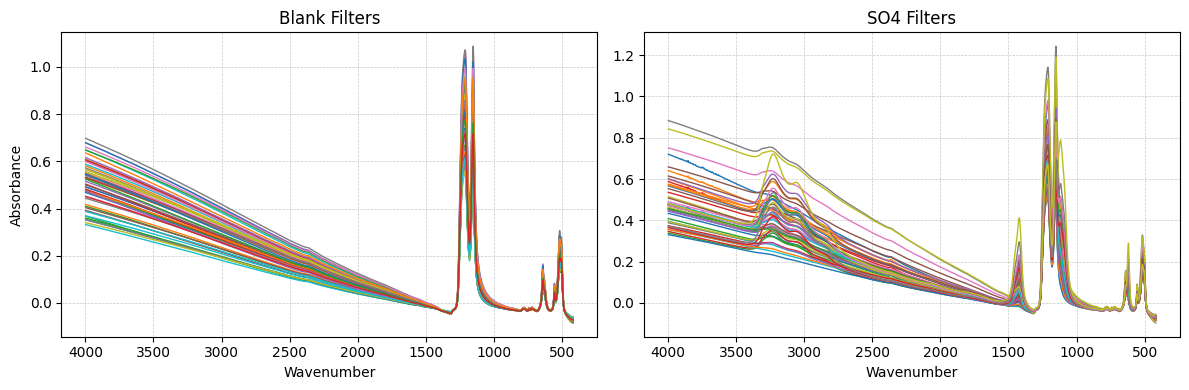

In [203]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))  

for i in range(Z.shape[0]):
    axs[0].plot(wn,Z[i,:], linewidth=1)
axs[0].set_xlabel("Wavenumber")
axs[0].set_ylabel("Absorbance")    
axs[0].invert_xaxis()
axs[0].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
axs[0].set_title("Blank Filters")

for i in range(Y.shape[0]):
    axs[1].plot(wn,Y[i,:], linewidth=1)
axs[1].set_xlabel("Wavenumber")   
axs[1].invert_xaxis()
axs[1].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
axs[1].set_title("SO4 Filters")

plt.tight_layout()
plt.show()

In [627]:
_ , chat_ose, _ = loo_pca(Z, detrend=True)
mu, _, _, W = pca(Z,detrend=True)
W = W[:,:chat_ose]
y = Y[40,:]

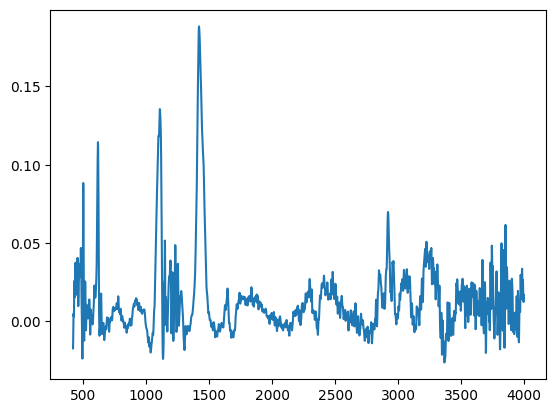

In [628]:
mod = EBS(loss="ALS")
mod.fit(y,mu,W)
plt.plot(wn,mod.absorbance)

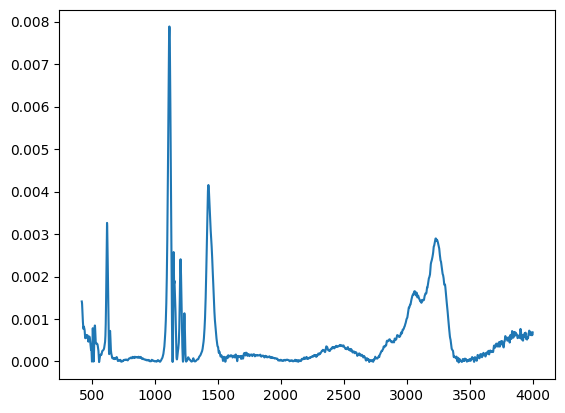

In [553]:
mod = VEB(c=W.shape[1],loss="ALS")
mod.fit(y,mu,W)
mod.map(y,mu,W)
plt.plot(wn,mod.absorbance)

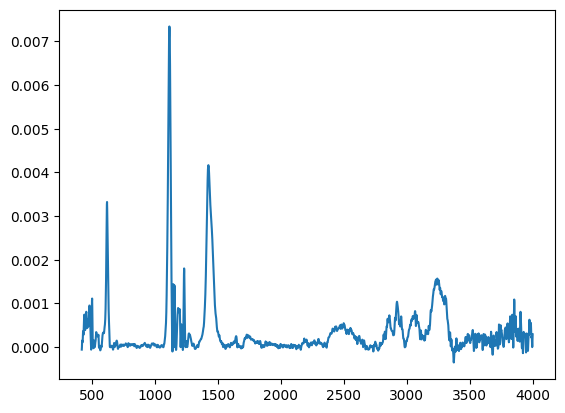

In [207]:
mod = EBS(loss="PB")
mod.fit(y,mu,W)
plt.plot(wn,mod.absorbance)

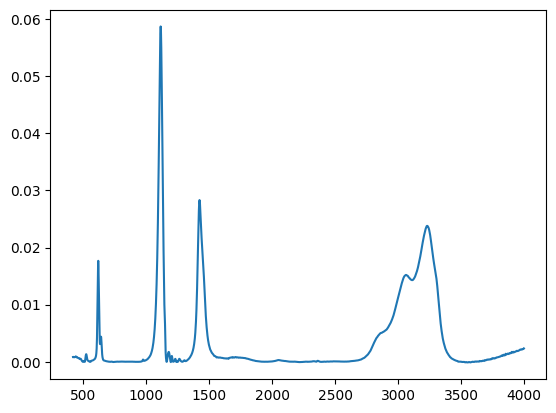

In [767]:
mod = VEB(c=W.shape[1],loss="PB")
mod.fit(y,mu,W,tau_min=0.1,tau_max=0.1)
mod.map(y,mu,W)
plt.plot(wn,mod.absorbance)
a = mod.absorbance

In [209]:
mu, _, _, W = pca(Z,detrend=True)
mod = VEB(c=1)
elbos = []
for c in tqdm(range(1,54)):
    mod.c = c
    mod.fit(y,mu,W[:,:c],mit=500)
    elbos.append(mod.elbo)
    
    if elbos[-1] == np.max(elbos):
        tau_init = mod.tau
        chat = c
        nu_init = mod.nu
        d_init = mod.d
                
    mod.tau_init = mod.tau
    mod.nu_init = np.append(mod.nu_init, 0)
    mod.d_init = np.append(mod.d_init, 1)

100%|██████████| 53/53 [00:25<00:00,  2.06it/s]


In [ ]:
mod = VEB(c=chat, tau_init=tau_init, nu_init=nu_init, d_init=d_init)
mod.fit(y,mu,W[:,:chat])
mod.map(y,mu,W[:,:chat])

In [744]:
tau = 0.10
c  = chat_ose
mu, _, _, W = pca(Z,detrend=True)
W = W[:,:c]

In [745]:
def pinball_loss(a, tau = 0.1):
    """
    Compute the pinball loss for quantile regression.
    """
    #return np.maximum(tau * a, (tau - 1) * a)
    return 0.5 * np.abs(a) + (tau - 0.5) * a

In [ ]:
y = Y[0,:]
sigma = 0.0001 
prev_sigma = None
loss_val = None
prev_loss_val = None
break_loop = False
folds = np.array_split(np.arange(y.shape[0]), 5)

In [763]:
while not break_loop:
    if loss_val == None:
        a = np.zeros(y.shape[0])
        for fold in folds:
            keep_idx = np.concatenate([f for f in folds if f is not fold])
            _,x =pb_map(y[keep_idx], mu[keep_idx], W[keep_idx,:], tau = tau, sigma = sigma)
            a[fold] = y[fold] - (mu[fold] + W[fold,:]@x)    
            
        loss_val = np.sum(pinball_loss(a, tau = tau))
        break_loop = False

    elif prev_sigma is None:
        a = np.zeros(y.shape[0])
        for fold in folds:
            keep_idx = np.concatenate([f for f in folds if f is not fold])
            _,x =pb_map(y[keep_idx], mu[keep_idx], W[keep_idx,:], tau = tau, sigma = sigma / 2)
            a[fold] = y[fold] - (mu[fold] + W[fold,:]@x)    
            
        loss_low = np.sum(pinball_loss(a, tau = tau))
        
        a = np.zeros(y.shape[0])
        for fold in folds:
            keep_idx = np.concatenate([f for f in folds if f is not fold])
            _,x =pb_map(y[keep_idx], mu[keep_idx], W[keep_idx,:], tau = tau, sigma = sigma * 2)
            a[fold] = y[fold] - (mu[fold] + W[fold,:]@x)    

        loss_high = np.sum(pinball_loss(a, tau = tau))

        prev_sigma = sigma
        prev_loss_val = loss_val

        if loss_low < loss_high:
            sigma = sigma / 2
        else:
            sigma = sigma * 2
            
        loss_val = min(loss_low, loss_high)
        
        if loss_val >= prev_loss_val:
            break_loop = True
        
    else:
        if sigma > prev_sigma:
            sigma_new = sigma * 2
        else:
            sigma_new = sigma / 2

        prev_sigma = sigma
        sigma = sigma_new
        prev_loss_val = loss_val
        
        a = np.zeros(y.shape[0])
        for fold in folds:
            keep_idx = np.concatenate([f for f in folds if f is not fold])
            _,x =pb_map(y[keep_idx], mu[keep_idx], W[keep_idx,:], tau = tau, sigma = sigma)
            a[fold] = y[fold] - (mu[fold] + W[fold,:]@x)    
        loss_val = np.sum(pinball_loss(a, tau = tau))
        
        if loss_val >= prev_loss_val:
            break_loop = True

    print(loss_val, sigma, prev_sigma, prev_loss_val)

17.730828880284932 0.0001 None None
13.771445616989709 0.0002 0.0001 17.730828880284932
10.260476922597991 0.0004 0.0002 13.771445616989709
7.951058813841865 0.0008 0.0004 10.260476922597991
6.50392643634067 0.0016 0.0008 7.951058813841865
6.364503591765305 0.0032 0.0016 6.50392643634067
7.758579923691812 0.0064 0.0032 6.364503591765305


In [799]:
def pinball_loss(a, tau = 0.1):
    """
    Compute the component-wise pinball loss.
    """
    return 0.5 * np.abs(a) + (tau - 0.5) * a

def als_loss(a, tau = 0.1):
    """
    Compute the component-wise asymmetrically weighted squared loss.
    """
    loss = a**2
    loss[a > 0] = tau*loss[a > 0]
    loss[a < 0] = (1-tau)*loss[a < 0]

    return loss

In [800]:
class MapCV:
    def __init__(
        self,
        y,
        mu,
        W,
        loss="PB",
        sigma = 0.0001,
        tau = 0.1,
        num_folds = 5,
    ):
        self.loss = loss
        self.sigma = sigma
        self.num_folds = num_folds
        self.tau = tau
        self.y = y
        self.mu = mu
        self.W = W
        self.folds = np.array_split(np.arange(y.shape[0]), num_folds)
        
        self.prev_sigma = None
        self.current_loss_val = None
        self.prev_loss_val = None
        self.break_loop = False
       
        if self.loss == "ALS":
            self.loss_fun = als_loss
            self.comp_map = als_map
        if self.loss == "PB":
            self.loss_fun = pinball_loss
            self.comp_map = pb_map

    def compute_cv_err(self, sigma):
        a = np.zeros(self.y.shape[0])
        for fold in self.folds:
            keep_idx = np.concatenate([f for f in self.folds if f is not fold])
            _,x = self.comp_map(self.y[keep_idx], self.mu[keep_idx], self.W[keep_idx,:], tau = self.tau, sigma = sigma)
            a[fold] = self.y[fold] - (self.mu[fold] + self.W[fold,:]@x)

        return np.sum(self.loss_fun(a, tau = self.tau))
    
    def initialize(self):
        self.prev_loss_val = self.compute_cv_err(self.sigma)
        loss_low = self.compute_cv_err(self.sigma / 2)
        loss_high = self.compute_cv_err(self.sigma * 2)

        self.prev_sigma = self.sigma
        if loss_low < loss_high:
            self.current_loss_val = loss_low
            self.sigma /= 2
        else:
            self.current_loss_val = loss_high
            self.sigma *= 2

    def search(self,mit=100):
        m = 0
        while not self.break_loop:
            if self.sigma > self.prev_sigma:
                sigma_new = self.sigma * 2
            else:
                sigma_new = self.prev_sigma / 2
                
            self.prev_sigma = self.sigma
            self.sigma = sigma_new
            self.prev_loss_val = self.current_loss_val
            self.current_loss_val = self.compute_cv_err(self.sigma)
            m += 1
            if m == mit or self.current_loss_val > self.prev_loss_val:
                self.break_loop = True
        
        self.sigma = self.prev_sigma
        self.current_loss_val = self.prev_loss_val
        
    def map(self,mit=100):
        self.interference, self.x = self.comp_map(
            self.y,
            self.mu,
            self.W,
            self.tau,
            self.sigma,
            mit,
            verbose=False,
        )
        self.absorbance = self.y - self.interference


In [7]:
chat_cv = loo_pca(Z)[1]
mu, _, _, W = pca(Z, detrend=True)
W = W[:, :chat_cv]

In [8]:
y = Y[0,:]

In [837]:
print(mod.current_loss_val)
tau = tau / 2
mod = MapCV(y,mu,W,loss="PB",tau=tau)
mod.initialize()
mod.search()
mod.map()
print(mod.current_loss_val)

5.044076140651101
5.190783813417601


In [9]:
mod = MapCV(y,mu,W,loss="ALS")
mod.initialize()
mod.search()
mod.map()
print(mod.current_loss_val)

0.02909559332761227


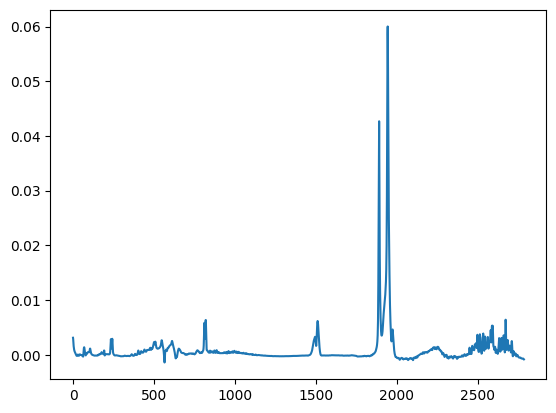

In [10]:
plt.plot(mod.absorbance)

In [ ]:
print(mod.prev_loss_val, )

0.20040600058982314 0.20040600058982314


In [821]:
mod.sigma

0.0008

np.float64(17.730828880284932)

In [779]:
mod.current_loss_val

np.float64(13.771445616989709)

In [775]:
mod.initialize()

In [776]:
mod.sigma

0.0002

In [777]:
mod.prev_sigma

0.0001

In [286]:
fold = folds[0]

array([   0,    1,    2, ..., 2225, 2226, 2227], shape=(2228,))

In [212]:
W = W[:, :48]

In [213]:
idx_keep = np.arange(2000)
idx_excl = np.arange(2000, y.shape[0])


In [ ]:
np.sum(pinball_loss(,tau=tau))

np.float64(0.14564262987398136)

In [278]:
z,x =pb_map(y, mu, W[:, :48], tau = tau, sigma = 0.0004)

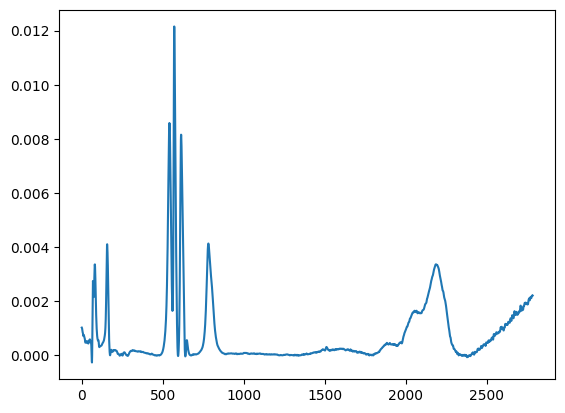

In [279]:
plt.plot(y-z)